# Explainable AI Framework for AC Optimal Power Flow (XAI for AC-OPF)

This notebook reproduces the main steps from the paper "An Explainable AI Framework for AC Optimal Power Flow" (IEEE Access, 2025) by Ronald Kfouri and Harag Margossian.

It demonstrates how to:
1. Load and preprocess the OPF-Learn dataset,
2. Train a feedforward neural network for AC-OPF prediction,
3. Evaluate its performance,
4. Interpret the model using Expected Gradients, SHAP, and Mean Attributions.

Note: This notebook assumes basic familiarity with Python, TensorFlow, and interpretability tools such as [Path Explain](https://github.com/suinleelab/path_explain) and [SHAP](https://github.com/shap/shap).

The algorithm is summarized in the below diagram:

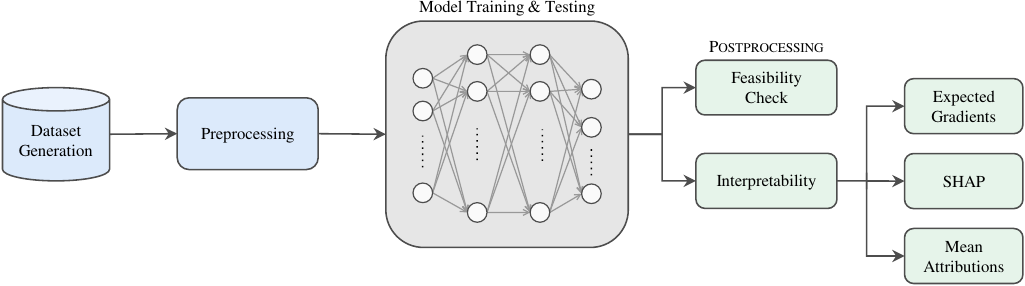


## Mount Google Drive (Colab Only)

If you're running this notebook on Google Colab, mount your Google Drive to access datasets or saved models.  
If you're running locally (on your own machine), skip this step.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## Install and import required libraries

In [ ]:
!pip install shap path-explain

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import shap
from path_explain import PathExplainerTF, softplus_activation, scatter_plot, summary_plot

## Load the data and preprocess it

The dataset was created using [OPF-Learn](https://ieeexplore.ieee.org/document/9817509) and saved in CSV format. I have not uploaded the dataset or code here, as they are not my original work. You can find the official implementation and example datasets in their [GitHub repository](https://github.com/NREL/OPFLearn.jl/).

Instructions:
* Update each file path (`YourPath/IEEE5Bus/...`) to match your local or Google Drive directory.
* Ensure that the training and testing files follow the same feature order and column structure.
* Data are standardized using `StandardScaler` to to facilitate faster convergence of gradient descent algorithms.

For the 5-bus case, the input features are the active and reactive load demands, given by $\mathbf{P_L} = \left[ P_{L2},\, P_{L3},\, P_{L4} \right]$ and $\mathbf{Q_L} = \left[ Q_{L2},\, Q_{L3},\, Q_{L4} \right]$, respectively.

The output features are the active power generation and voltage magnitude at each generator, denoted by $\mathbf{P_g} = \left[ P_{g_1},\, \ldots,\, P_{g_5} \right]$ and $|\mathbf{V_g}| = \left[ |V_{g_1}|,\, \ldots,\, |V_{g_5}| \right]$, respectively. The neural network in this notebook considers only $\mathbf{P_g}$.

The 5-bus system is shown below:

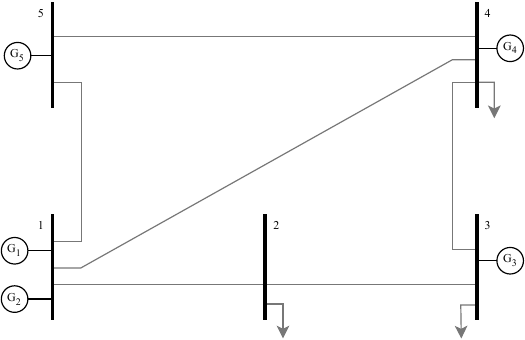

In [ ]:
# Load the data
X_path = "YourPath/IEEE5Bus/5Bus_Training_Inputs.csv" # Update with your path; the columns here should be: P_L2, P_L3, P_L4, Q_L2, Q_L3, Q_L4
Y_path = "YourPath/IEEE5Bus/5Bus_Training_Outputs_For_PG.csv" # Update with your path; the columns here should be: P_G1, P_G2, P_G3, P_G4, P_G5
X_path_testing = "YourPath/IEEE5Bus/5Bus_Testing_Inputs.csv" # Update with your path; the columns here should be: P_L2, P_L3, P_L4, Q_L2, Q_L3, Q_L4
Y_path_testing = "YourPath/IEEE5Bus/5Bus_Testing_Outputs_For_PG.csv" # Update with your path; the columns here should be: P_G1, P_G2, P_G3, P_G4, P_G5

Input_data_frame = pd.read_csv(X_path)
Output_data_frame = pd.read_csv(Y_path)
Input_data_frame_testing = pd.read_csv(X_path_testing)
Output_data_frame_testing = pd.read_csv(Y_path_testing)

# Convert to numpy arrays
x_input = Input_data_frame.to_numpy()
x_input_testing = Input_data_frame_testing.to_numpy()
y_output = Output_data_frame.to_numpy()
y_test = Output_data_frame_testing.to_numpy()

# Standardize the data
scaler = StandardScaler()
x_input = scaler.fit_transform(x_input)
x_input_testing = scaler.transform(x_input_testing)

## Hyperparameter Optimization

In this section, we perform a grid search to identify the best neural network architecture for the AC-OPF neural network.  
The search explores combinations of:
- Number of neurons per hidden layer (32, 64, 128, 256), and  
- Number of hidden layers (2 to 6).

For each configuration:
- A feedforward neural network is defined and trained using an 80/20 validation split.  
- The model’s Mean Squared Error (MSE) on the test set is recorded.  
- The best-performing configuration (lowest test MSE) is selected.

Finally, the training and validation MSE curves of the best model are plotted for visual comparison.

Note:
- Training may take several minutes depending on hardware.  
- You can reduce the number of epochs or combinations for faster testing.
- Once the best neural network architecture is selected, the neural network can be saved (using your favorite method/extension) and then feasibility can be checked on the predicted outputs. This is done in a separate notebook, which will be uploaded soon.

In [ ]:
# Define the grid search parameters
neurons_per_layer = [32, 64, 128, 256]
num_hidden_layers = [2, 3, 4, 5, 6]

# Store the results
results = []

# Perform grid search
for neurons in neurons_per_layer:
    for layers in num_hidden_layers:
        print(f"Training model with {neurons} neurons and {layers} hidden layers...")

        # Define the neural network model
        model = keras.Sequential()
        model.add(keras.layers.Dense(neurons, input_shape=(x_input.shape[1],), activation='relu'))

        for _ in range(layers - 1):
            model.add(keras.layers.Dense(neurons, activation='relu'))

        model.add(keras.layers.Dense(y_output.shape[1]))

        # Compile the model
        model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mse'])

        # Train the model
        history = model.fit(x_input, y_output, validation_split=0.2, shuffle=True, epochs=100, batch_size=32, verbose=0)

        # Evaluate the model on the test set
        test_loss, test_mse = model.evaluate(x_input_testing, y_test, verbose=0)

        # Store the results
        results.append({
            'neurons': neurons,
            'layers': layers,
            'test_mse': test_mse,
            'history': history
        })

        print(f"Test MSE for {neurons} neurons and {layers} layers: {test_mse}")

# Find the best model based on test MSE
best_result = min(results, key=lambda x: x['test_mse'])
print(f"Best model: {best_result['neurons']} neurons, {best_result['layers']} layers, Test MSE: {best_result['test_mse']}")

# Plot training & validation MSE values for the best model
plt.plot(best_result['history'].history['mse'], label='Train MSE')
plt.plot(best_result['history'].history['val_mse'], label='Validation MSE')
plt.title(f"Model MSE ({best_result['neurons']} neurons, {best_result['layers']} layers)")
plt.ylabel('MSE')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.show()

# Save the trained neural network using your favorite method/extension

## Model Interpretability using SHAP

In this section, the trained neural network is interpreted using the SHAP framework. SHAP assigns an importance value (Shapley value) to each input feature, indicating how much that feature contributes to the model’s prediction.

Steps:
1. The trained model is wrapped using `shap.DeepExplainer`.  
2. SHAP values are computed for a subset of the test data (`x_input_testing[:100]`).  
3. A summary plot is generated to visualize the most influential input features affecting the model output.

Notes:  
- Ensure that the order of `latex_feature_names` matches the column order in your CSV input files.
- Update the save path (`YourPath/IEEE5Bus/...`) before running the final `plt.savefig()` command.
- The resulting figure highlights the most significant features influencing the predicted generator outputs.

In [ ]:
# Print TensorFlow version
# print("TensorFlow Version:", tf.__version__)

# Convert feature names to a NumPy array
latex_feature_names = np.array([ # The order of the feature names should be the same as in the csv files
    r'$P_{L2}$',
    r'$P_{L3}$',
    r'$P_{L4}$',
    r'$Q_{L2}$',
    r'$Q_{L3}$',
    r'$Q_{L4}$',
])

# Convert input to NumPy array
x_input_testing = np.array(x_input_testing, dtype=np.float32)

# Interpret the best model using SHAP
explainer_shap = shap.DeepExplainer(model, x_input[:100])
shap_values = explainer_shap.shap_values(x_input_testing[:100])

# Debugging print statements
# print("SHAP values shape:", np.array(shap_values).shape)  # Should be (num_samples, num_features, num_outputs)
# print("Input data shape:", x_input_testing[:100].shape)  # Should be (num_samples, num_features)

# Select SHAP values for the first output
shap_values_selected = shap_values[:, :, 0]  # Select SHAP values for the first output (shape: (100, 6))

# Debugging print statements
# print("Selected SHAP values shape:", shap_values_selected.shape)
# print("Feature names length:", len(latex_feature_names))

# Ensure the shapes match
assert shap_values_selected.shape == x_input_testing[:100].shape, (
    f"Shape mismatch: SHAP values {shap_values_selected.shape} != input data {x_input_testing[:100].shape}"
)

# SHAP Summary Plot
shap.summary_plot(shap_values_selected, x_input_testing[:100], feature_names=latex_feature_names.tolist(), max_display=6)

# Save the plot
plt.savefig('YourPath/IEEE5Bus/Shap_top_10_features.pdf', bbox_inches='tight') # Update with your path

# Show the plot
plt.show()

## Model Interpretability using Expected Gradients

This section applies the Expected Gradients method to interpret the neural network’s predictions.

Steps:
1. Model cloning: The trained neural network is cloned and all ReLU activations are replaced with SoftPlus to ensure differentiability (as required by gradient-based methods).
2. Attribution computation: Path Explain computes feature attributions using multiple random baselines and sample paths (the main difference with Integrated Gradients).
3. Visualization: A summary plot highlights the top influential features affecting the model outputs.

Notes:  
- Ensure that the order of `latex_feature_names` matches the feature order in your dataset.  
- Update the path in `plt.savefig('YourPath/IEEE5Bus/…')` before running this cell.  
- The resulting figure illustrates the most influential features, complementing the SHAP-based interpretability results.


In [ ]:
# Interpret the model using path-explain
# Clone the model and change the activation function to SoftPlus (ReLU is non-differentiable at zero)
# You can check the papers on the following papers: https://arxiv.org/abs/1906.10670 | https://www.jmlr.org/papers/v22/20-1223.html
interpret_model = keras.models.clone_model(model)
interpret_model.set_weights(model.get_weights())
for layer in interpret_model.layers:
    if hasattr(layer, 'activation') and layer.activation == tf.keras.activations.relu:
        layer.activation = softplus_activation(beta=10.0)

# Compile the interpretable model
interpret_model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mse'])

# LaTeX-formatted feature names
latex_feature_names = [
    r'$P_{L2}$',
    r'$P_{L3}$',
    r'$P_{L4}$',
    r'$Q_{L2}$',
    r'$Q_{L3}$',
    r'$Q_{L4}$',
]

# Generate attributions using Expected Gradients
explainer_path = PathExplainerTF(interpret_model)
attributions = explainer_path.attributions(inputs=x_input_testing.astype(np.float32),
                                      baseline=x_input.astype(np.float32),
                                      batch_size=100,
                                      num_samples=200,
                                      use_expectation=True,
                                      output_indices=0,
                                      verbose=True)

# Visualize the top 10 features using path-explain
summary_plot(attributions=attributions,
             feature_values=x_input_testing,
             feature_names=latex_feature_names,
             plot_top_k=6)
plt.rcParams['text.usetex'] = True

plt.savefig('YourPath/IEEE5Bus/pathexplain_top_10_features.pdf') # Update with your path
plt.show()

## Feature Attribution Visualization

In this section, the feature attributions obtained from the Expected Gradients method are visualized individually for each output variable.  
This representation is introduced in this paper and shows how each input feature contributes to the prediction of a specific generator output (e.g., $P_{G1}$, $P_{G2}$, etc.).

Steps:
1. Specify the target output index (`output_index`) to analyze one generator output at a time.  
2. Compute Expected Gradient attributions for that output using the `PathExplainerTF`.  
3. Plot the mean absolute attributions as a bar chart to highlight which input features most influence that particular output.

Notes:
- Change `output_index` to analyze other generator outputs.  
- Ensure the order of `latex_feature_names` matches the feature order in your dataset.  
- Update the save path (`YourPath/IEEE5Bus/...`) before running.  
- LaTeX rendering is disabled to avoid compatibility issues in some environments.

This output-specific attribution visualization provides a clear and interpretable link between the inputs (active and reactive loads) and the predicted generator powers, enhancing the transparency and explainability of the neural network model.


In [ ]:
output_index = 0  # Change this to analyze other outputs

# Compute attributions for the specified output index
attributions = explainer_path.attributions(
    inputs=x_input_testing.astype(np.float32),
    baseline=x_input.astype(np.float32),
    batch_size=100,
    num_samples=200,
    use_expectation=True,
    output_indices=output_index,  # Focus on the specified output
    verbose=True
)

# Disable LaTeX rendering to avoid the 'latex not found' error
plt.rcParams['text.usetex'] = False


# Define LaTeX-style feature names
latex_feature_names = [
    r'$P_{L2}$',
    r'$P_{L3}$',
    r'$P_{L4}$',
    r'$Q_{L2}$',
    r'$Q_{L3}$',
    r'$Q_{L4}$',
]

# Visualize the attributions
plt.figure(figsize=(10, 6))
plt.bar(range(attributions.shape[1]), np.mean(np.abs(attributions), axis=0))
plt.xticks(range(attributions.shape[1]), latex_feature_names, rotation=0)
plt.xlabel("Input Features")
plt.ylabel("Mean Attribution Value")

# Format the title with subscript using LaTeX
plt.title(f"Feature Attributions for Output $P_G{output_index + 1}$")
plt.tight_layout()


# Save the plot (optional)
plt.savefig(f"YourPath/IEEE5Bus/PathExplain_Attributions_P{output_index + 1}.pdf") # Update with your path
plt.show()


In [ ]:
output_index = 1  # Change this to analyze other outputs

# Compute attributions for the specified output index
attributions = explainer_path.attributions(
    inputs=x_input_testing.astype(np.float32),
    baseline=x_input.astype(np.float32),
    batch_size=100,
    num_samples=200,
    use_expectation=True,
    output_indices=output_index,  # Focus on the specified output
    verbose=True
)

# Disable LaTeX rendering to avoid the 'latex not found' error
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

# Define LaTeX-style feature names
latex_feature_names = [
    r'$P_{L2}$',
    r'$P_{L3}$',
    r'$P_{L4}$',
    r'$Q_{L2}$',
    r'$Q_{L3}$',
    r'$Q_{L4}$',
]

# Visualize the attributions
plt.figure(figsize=(10, 6))
plt.bar(range(attributions.shape[1]), np.mean(np.abs(attributions), axis=0))
plt.xticks(range(attributions.shape[1]), latex_feature_names, rotation=0)
plt.xlabel("Input Features")
plt.ylabel("Mean Attribution Value")

# Format the title with subscript using LaTeX
plt.title(f"Feature Attributions for Output $P_{{{output_index + 1}}}$")
plt.tight_layout()


# Save the plot (optional)
plt.savefig(f"YourPath/IEEE5Bus/PathExplain_Attributions_P{output_index + 1}.pdf") # Update with your path
plt.show()


In [ ]:
output_index = 2  # Change this to analyze other outputs

# Compute attributions for the specified output index
attributions = explainer_path.attributions(
    inputs=x_input_testing.astype(np.float32),
    baseline=x_input.astype(np.float32),
    batch_size=100,
    num_samples=200,
    use_expectation=True,
    output_indices=output_index,  # Focus on the specified output
    verbose=True
)

# Disable LaTeX rendering to avoid the 'latex not found' error
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

# Define LaTeX-style feature names
latex_feature_names = [
    r'$P_{L2}$',
    r'$P_{L3}$',
    r'$P_{L4}$',
    r'$Q_{L2}$',
    r'$Q_{L3}$',
    r'$Q_{L4}$',
]

# Visualize the attributions
plt.figure(figsize=(10, 6))
plt.bar(range(attributions.shape[1]), np.mean(np.abs(attributions), axis=0))
plt.xticks(range(attributions.shape[1]), latex_feature_names, rotation=0)
plt.xlabel("Input Features")
plt.ylabel("Mean Attribution Value")

# Format the title with subscript using LaTeX
plt.title(f"Feature Attributions for Output $P_{{{output_index + 1}}}$")
plt.tight_layout()


# Save the plot (optional)
plt.savefig(f"YourPath/IEEE5Bus/PathExplain_Attributions_P{output_index + 1}.pdf") # Update with your path
plt.show()


In [ ]:
output_index = 3  # Change this to analyze other outputs

# Compute attributions for the specified output index
attributions = explainer_path.attributions(
    inputs=x_input_testing.astype(np.float32),
    baseline=x_input.astype(np.float32),
    batch_size=100,
    num_samples=200,
    use_expectation=True,
    output_indices=output_index,  # Focus on the specified output
    verbose=True
)

# Disable LaTeX rendering to avoid the 'latex not found' error
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

# Define LaTeX-style feature names
latex_feature_names = [
    r'$P_{L2}$',
    r'$P_{L3}$',
    r'$P_{L4}$',
    r'$Q_{L2}$',
    r'$Q_{L3}$',
    r'$Q_{L4}$',
]

# Visualize the attributions
plt.figure(figsize=(10, 6))
plt.bar(range(attributions.shape[1]), np.mean(np.abs(attributions), axis=0))
plt.xticks(range(attributions.shape[1]), latex_feature_names, rotation=0)
plt.xlabel("Input Features")
plt.ylabel("Mean Attribution Value")

# Format the title with subscript using LaTeX
plt.title(f"Feature Attributions for Output $P_{{{output_index + 1}}}$")
plt.tight_layout()


# Save the plot (optional)
plt.savefig(f"YourPath/IEEE5Bus/PathExplain_Attributions_P{output_index + 1}.pdf") # Update with your path
plt.show()


In [ ]:
output_index = 4  # Change this to analyze other outputs

# Compute attributions for the specified output index
attributions = explainer_path.attributions(
    inputs=x_input_testing.astype(np.float32),
    baseline=x_input.astype(np.float32),
    batch_size=100,
    num_samples=200,
    use_expectation=True,
    output_indices=output_index,  # Focus on the specified output
    verbose=True
)

# Disable LaTeX rendering to avoid the 'latex not found' error
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

# Define LaTeX-style feature names
latex_feature_names = [
    r'$P_{L2}$',
    r'$P_{L3}$',
    r'$P_{L4}$',
    r'$Q_{L2}$',
    r'$Q_{L3}$',
    r'$Q_{L4}$',
]

# Visualize the attributions
plt.figure(figsize=(10, 6))
plt.bar(range(attributions.shape[1]), np.mean(np.abs(attributions), axis=0))
plt.xticks(range(attributions.shape[1]), latex_feature_names, rotation=0)
plt.xlabel("Input Features")
plt.ylabel("Mean Attribution Value")

# Format the title with subscript using LaTeX
plt.title(f"Feature Attributions for Output $P_{{{output_index + 1}}}$")
plt.tight_layout()


# Save the plot (optional)
plt.savefig(f"YourPath/IEEE5Bus/PathExplain_Attributions_P{output_index + 1}.pdf") # Update with your path
plt.show()


Finally, the same approach is done for $|\mathbf{V_g}|$, the voltage magnitudes. This will be uploaded soon.